In [1]:
from google.colab import files
uploaded = files.upload()

Saving InShot_20260714_023714044.mp4 to InShot_20260714_023714044.mp4


In [2]:
!pip install moviepy

In [3]:
import moviepy
print(moviepy.__version__)

2.1.2


In [4]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [5]:
!ls

InShot_20260714_023714044.mp4  sample_data


In [6]:
!ffmpeg -y -i "InShot_20260714_023714044.mp4" -vn -acodec pcm_s16le -ar 44100 -ac 1 AV_01.wav


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [7]:
import librosa
import matplotlib.pyplot as plt

# Load audio
y, sr = librosa.load("AV_01.wav", sr=None)

print("Sample Rate :", sr)
print("Duration :", librosa.get_duration(y=y, sr=sr))
print("Total Samples :", len(y))

Sample Rate : 44100
Duration : 28.978503401360545
Total Samples : 1277952


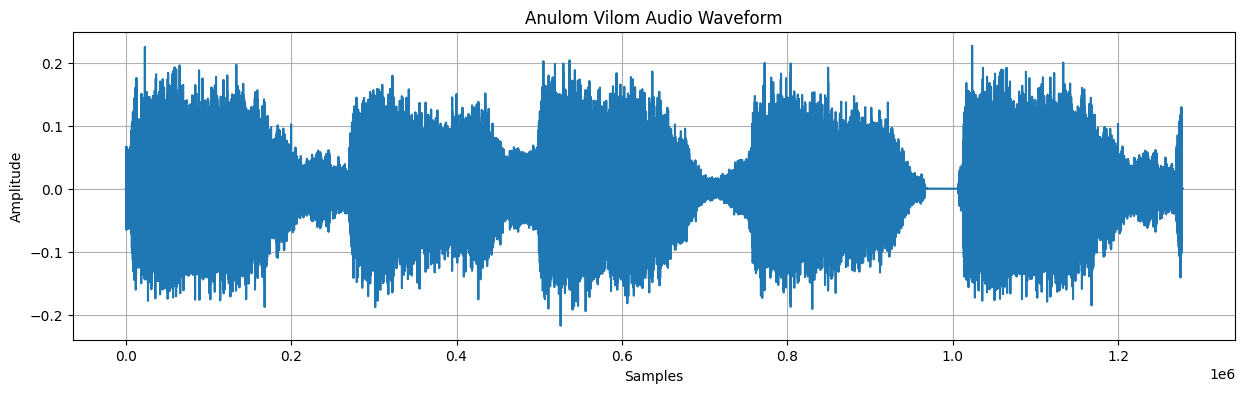

In [8]:
plt.figure(figsize=(15,4))
plt.plot(y)

plt.title("Anulom Vilom Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

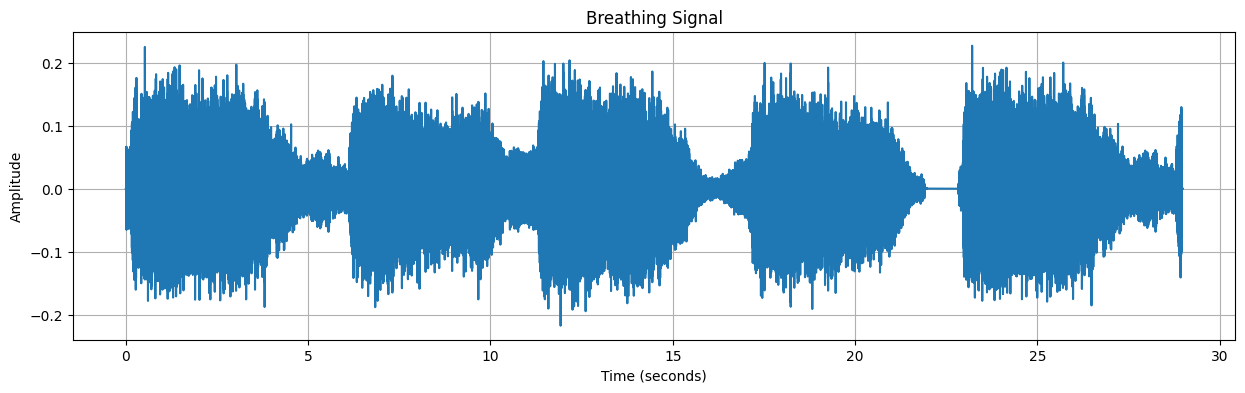

In [9]:
import numpy as np

time = np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(15,4))
plt.plot(time, y)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Breathing Signal")

plt.grid()

plt.show()

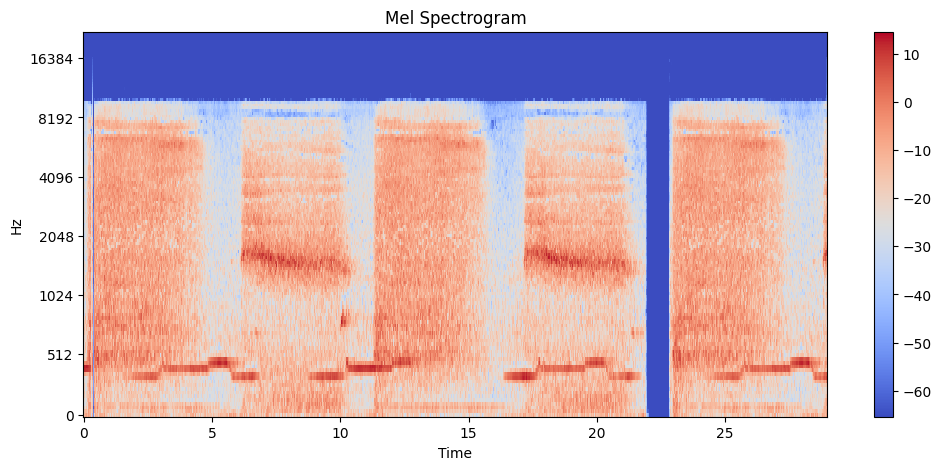

In [10]:
import librosa.display

mel = librosa.feature.melspectrogram(y=y, sr=sr)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

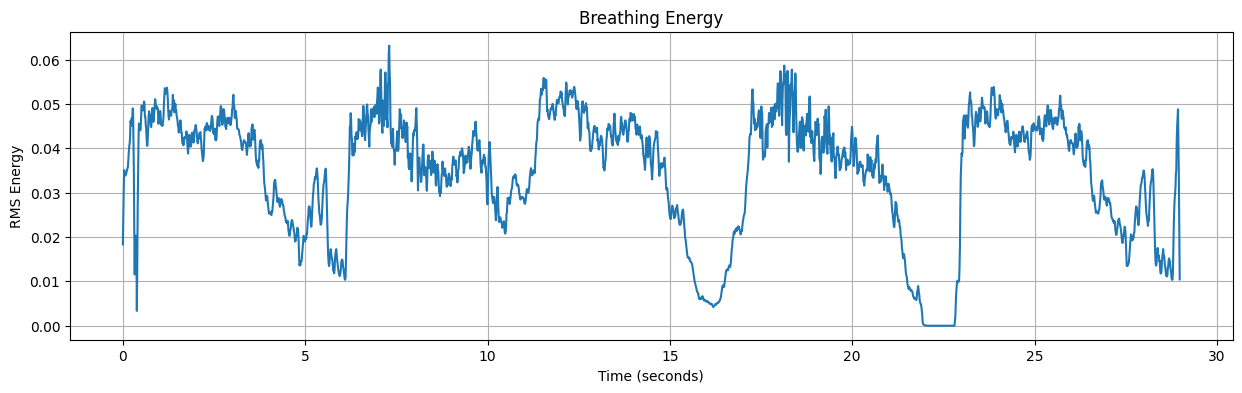

In [11]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load("AV_01.wav", sr=None)

frame_length = 2048
hop_length = 512

rms = librosa.feature.rms(
    y=y,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times = librosa.times_like(
    rms,
    sr=sr,
    hop_length=hop_length
)

plt.figure(figsize=(15,4))
plt.plot(times, rms)

plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")

plt.title("Breathing Energy")

plt.grid()

plt.show()

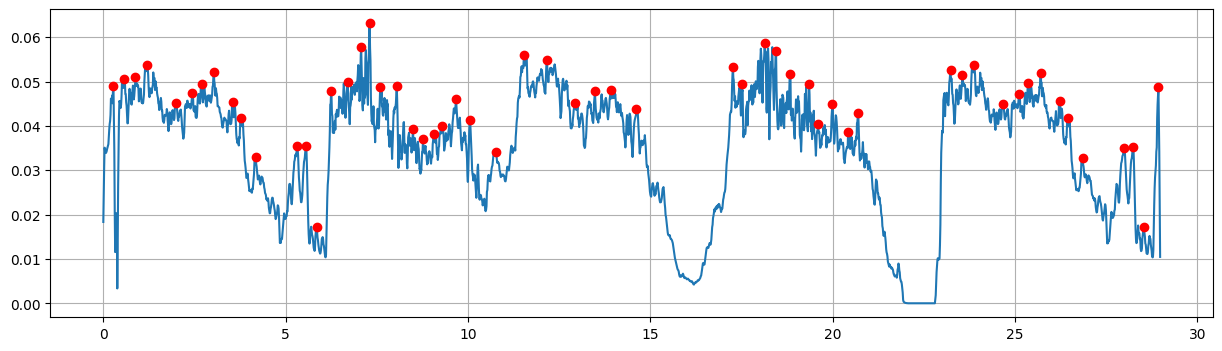

Detected peaks: 57


In [12]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(
    rms,
    distance=20,
    prominence=0.005
)

plt.figure(figsize=(15,4))
plt.plot(times, rms)
plt.plot(times[peaks], rms[peaks], "ro")

plt.grid()
plt.show()

print("Detected peaks:", len(peaks))

In [13]:
duration = librosa.get_duration(y=y, sr=sr)

breathing_rate = len(peaks) * 60 / duration

print("Estimated Breaths per Minute:", breathing_rate)

Estimated Breaths per Minute: 118.01851712740384


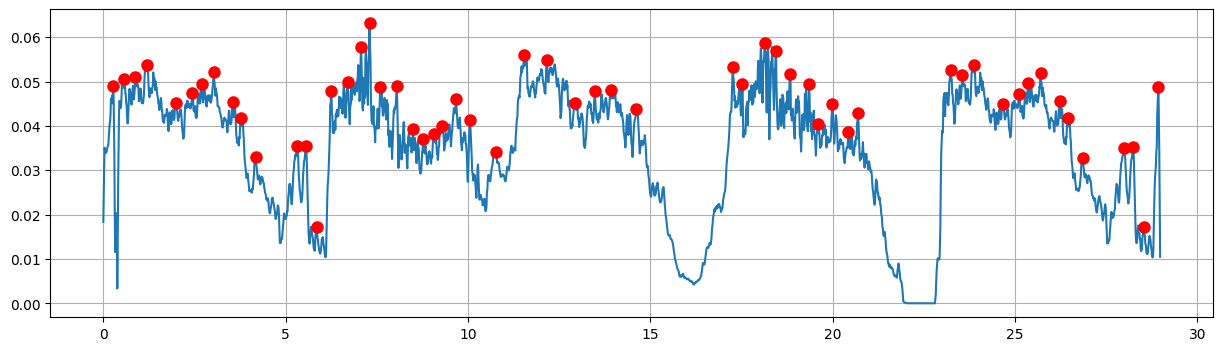

In [14]:
plt.figure(figsize=(15,4))

plt.plot(times, rms)

plt.plot(times[peaks], rms[peaks], "ro", markersize=8)

plt.grid()

plt.show()

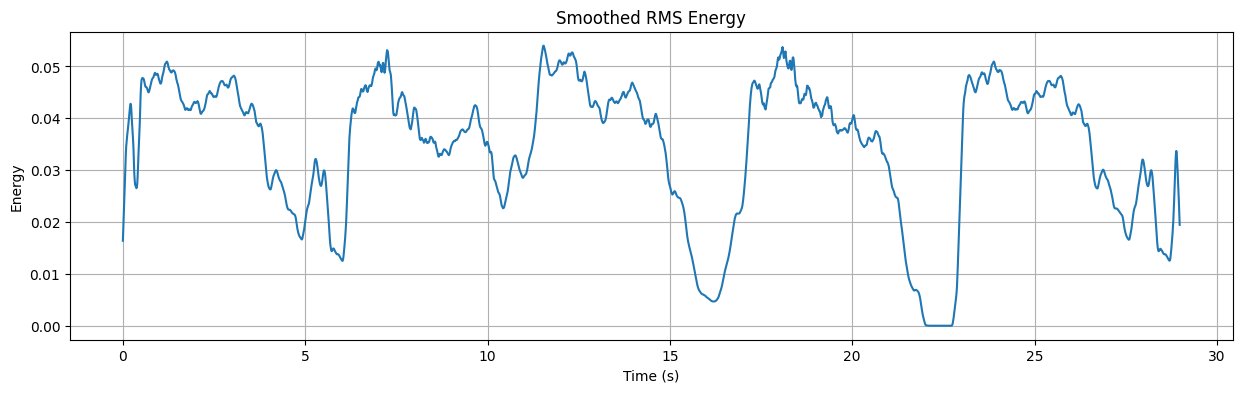

In [15]:
import numpy as np

window_size = 15
rms_smooth = np.convolve(rms, np.ones(window_size)/window_size, mode='same')

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.title("Smoothed RMS Energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.grid()
plt.show()

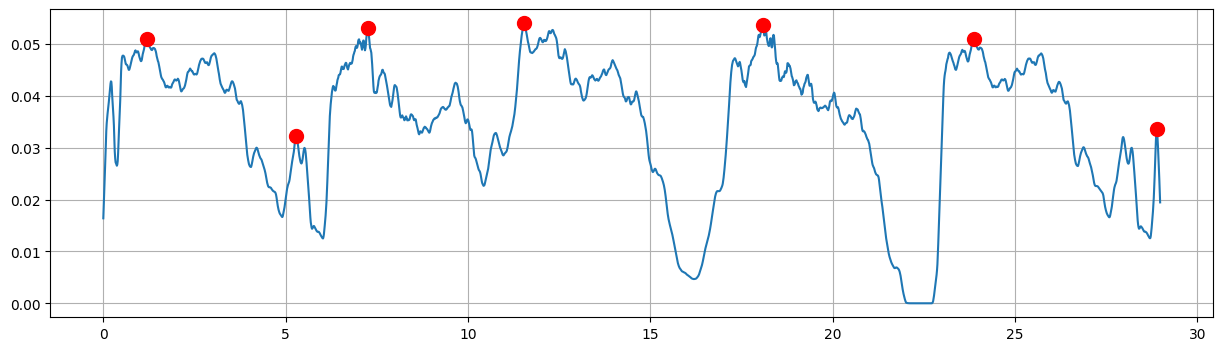

Number of Peaks: 7


In [16]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    rms_smooth,
    distance=120,
    prominence=0.01
)

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.plot(times[peaks], rms_smooth[peaks], "ro", markersize=10)

plt.grid()
plt.show()

print("Number of Peaks:", len(peaks))

In [17]:
duration = librosa.get_duration(y=y, sr=sr)

breathing_rate = len(peaks) * 60 / duration

print("Estimated Breaths per Minute:", breathing_rate)

Estimated Breaths per Minute: 14.493502103365385


In [18]:
print("Total Breathing Cycles :", len(peaks))

Total Breathing Cycles : 7


In [19]:
peak_times = times[peaks]

print(peak_times)

[ 1.20743764  5.28253968  7.24462585 11.54031746 18.08834467 23.88172336
 28.88562358]


In [20]:
cycle_duration = np.diff(peak_times)

print(cycle_duration)

[4.07510204 1.96208617 4.29569161 6.54802721 5.79337868 5.00390023]


In [21]:
avg_cycle = np.mean(cycle_duration)

print("Average Cycle Duration =", avg_cycle)

Average Cycle Duration = 4.613030990173847


In [22]:
breathing_rate = 60 / avg_cycle

print("Breathing Frequency =", breathing_rate)

Breathing Frequency = 13.006632760067115


In [23]:
std_cycle = np.std(cycle_duration)

print("Rhythm Consistency (STD) =", std_cycle)

Rhythm Consistency (STD) = 1.4553229940776282


In [24]:
print("Maximum Cycle =", np.max(cycle_duration))


Maximum Cycle = 6.548027210884353


In [25]:
print("Minimum Cycle =", np.min(cycle_duration))

Minimum Cycle = 1.9620861678004538


In [26]:
print("Average RMS =", np.mean(rms_smooth))

Average RMS = 0.03470105092041334


In [27]:
print("Maximum RMS =", np.max(rms_smooth))

Maximum RMS = 0.05399443159500758


In [28]:
import pandas as pd

results = pd.DataFrame({
    "Parameter": [
        "Duration (s)",
        "Detected Peaks",
        "Breathing Frequency (breaths/min)",
        "Average Cycle Duration (s)",
        "Rhythm Consistency (STD)",
        "Maximum Cycle Duration (s)",
        "Minimum Cycle Duration (s)",
        "Average RMS Energy",
        "Maximum RMS Energy"
    ],
    "Value": [
        librosa.get_duration(y=y, sr=sr),
        len(peak_times),
        breathing_rate,
        avg_cycle,
        std_cycle,
        np.max(cycle_duration),
        np.min(cycle_duration),
        np.mean(rms_smooth),
        np.max(rms_smooth)
    ]
})

results

,Parameter,Value
0,Duration (s),28.978503
1,Detected Peaks,7.000000
2,Breathing Frequency (breaths/min),13.006633
3,Average Cycle Duration (s),4.613031
4,Rhythm Consistency (STD),1.455323
5,Maximum Cycle Duration (s),6.548027
6,Minimum Cycle Duration (s),1.962086
7,Average RMS Energy,0.034701
8,Maximum RMS Energy,0.053994


In [29]:
results.to_csv("Quantitative_Results.csv", index=False)

In [30]:
print(cycle_duration)

[4.07510204 1.96208617 4.29569161 6.54802721 5.79337868 5.00390023]


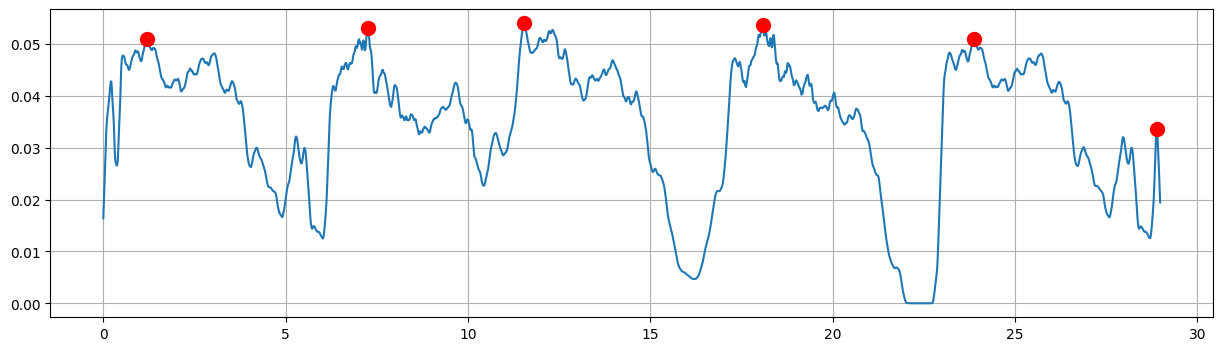

Peak Times: [ 1.20743764  7.24462585 11.54031746 18.08834467 23.88172336 28.88562358]
Number of Peaks: 6


In [31]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    rms_smooth,
    distance=180,
    prominence=0.012
)

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.plot(times[peaks], rms_smooth[peaks], "ro", markersize=10)
plt.grid()
plt.show()

print("Peak Times:", times[peaks])
print("Number of Peaks:", len(peaks))

In [32]:
total_cycles = len(peaks)

print("Total Breathing Cycles:", total_cycles)

Total Breathing Cycles: 6


In [33]:
cycle_duration = np.diff(times[peaks])

print(cycle_duration)

[6.03718821 4.29569161 6.54802721 5.79337868 5.00390023]


In [34]:
avg_cycle = np.mean(cycle_duration)

print(avg_cycle)

5.535637188208616


In [35]:
breathing_rate = 60/avg_cycle

print("Breathing Frequency =",breathing_rate)

Breathing Frequency = 10.838860633389263


In [36]:
std_cycle=np.std(cycle_duration)

print(std_cycle)

0.7953775073892267


In [37]:
avg_energy = np.mean(rms_smooth)
print("Average RMS Energy:", avg_energy)

Average RMS Energy: 0.03470105092041334


In [38]:
max_energy = np.max(rms_smooth)
print("Maximum RMS Energy:", max_energy)

Maximum RMS Energy: 0.05399443159500758


In [39]:
min_energy = np.min(rms_smooth)
print("Minimum RMS Energy:", min_energy)

Minimum RMS Energy: 0.0


In [40]:
import pandas as pd

results = pd.DataFrame({
    "Parameter": [
        "Audio Duration (s)",
        "Detected Breathing Cycles",
        "Average Cycle Duration (s)",
        "Breathing Frequency (breaths/min)",
        "Rhythm Consistency (STD)",
        "Average RMS Energy",
        "Maximum RMS Energy",
        "Minimum RMS Energy"
    ],
    "Value": [
        librosa.get_duration(y=y, sr=sr),
        total_cycles,
        avg_cycle,
        breathing_rate,
        std_cycle,
        avg_energy,
        max_energy,
        min_energy
    ]
})

print(results)

results.to_csv("Quantitative_Report.csv", index=False)

                           Parameter      Value
0                 Audio Duration (s)  28.978503
1          Detected Breathing Cycles   6.000000
2         Average Cycle Duration (s)   5.535637
3  Breathing Frequency (breaths/min)  10.838861
4           Rhythm Consistency (STD)   0.795378
5                 Average RMS Energy   0.034701
6                 Maximum RMS Energy   0.053994
7                 Minimum RMS Energy   0.000000


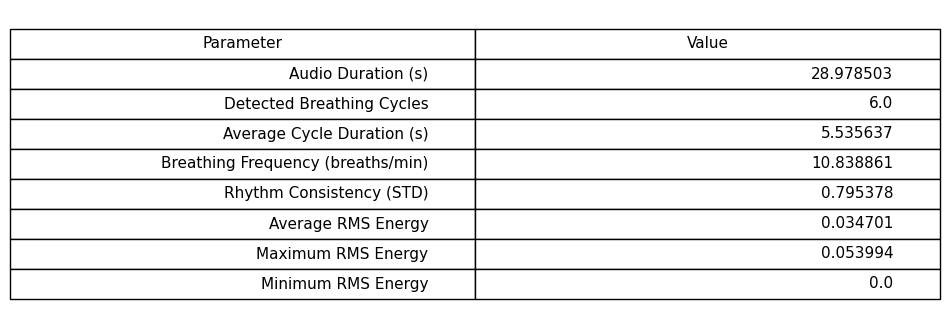

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Your dataframe
results = pd.DataFrame({
    "Parameter": [
        "Audio Duration (s)",
        "Detected Breathing Cycles",
        "Average Cycle Duration (s)",
        "Breathing Frequency (breaths/min)",
        "Rhythm Consistency (STD)",
        "Average RMS Energy",
        "Maximum RMS Energy",
        "Minimum RMS Energy"
    ],
    "Value": [
        28.978503,
        6,
        5.535637,
        10.838861,
        0.795378,
        0.034701,
        0.053994,
        0.000000
    ]
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.savefig("quantitative_results.png", dpi=300, bbox_inches='tight')
plt.show()